In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import os

In [5]:
from sklearn.datasets import make_regression
X, y = make_regression(n_samples=100, n_features=1, noise=10, random_state=42)
df = pd.DataFrame({'YearsExperience': X.flatten(), 'Salary': y})

print("First 5 rows:")
print(df.head())

First 5 rows:
   YearsExperience     Salary
0         0.931280  50.779929
1         0.087047 -10.065270
2        -1.057711 -34.918392
3         0.314247  10.526743
4        -0.479174 -17.738377



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  100 non-null    float64
 1   Salary           100 non-null    float64
dtypes: float64(2)
memory usage: 1.7 KB
None

Summary statistics:
       YearsExperience      Salary
count       100.000000  100.000000
mean         -0.103847   -3.449530
std           0.908168   41.321720
min          -2.619745 -118.027454
25%          -0.600906  -30.170786
50%          -0.126956   -0.634702
75%           0.405952   23.478589
max           1.852278   89.033145


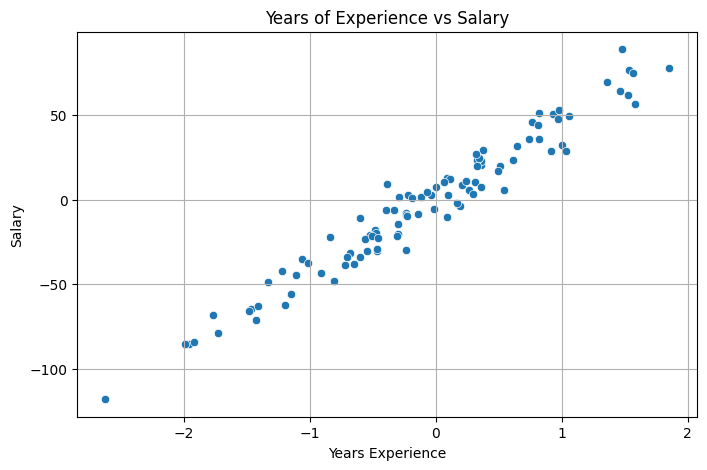

In [6]:
print("\nDataset info:")
print(df.info())
print("\nSummary statistics:")
print(df.describe())

# Scatter plot
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='YearsExperience', y='Salary')
plt.title('Years of Experience vs Salary')
plt.xlabel('Years Experience')
plt.ylabel('Salary')
plt.grid(True)
plt.savefig('scatter_plot.png')
plt.show()

In [7]:
# --------------------------
# 3. Prepare features and target
# --------------------------
X = df[['YearsExperience']]  # DataFrame (2D)
y = df['Salary']  

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")


Training samples: 80
Test samples: 20


In [9]:
model = LinearRegression()
model.fit(X_train, y_train)

# Model parameters
print(f"\nIntercept: {model.intercept_:.2f}")
print(f"Coefficient: {model.coef_[0]:.2f}")


Intercept: 0.10
Coefficient: 44.24


In [10]:
# --------------------------
# 6. Evaluate
# --------------------------
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n--- Model Performance ---")
print(f"MAE:  {mae:.2f}")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.4f}")


--- Model Performance ---
MAE:  8.42
MSE:  104.20
RMSE: 10.21
R²:   0.9374


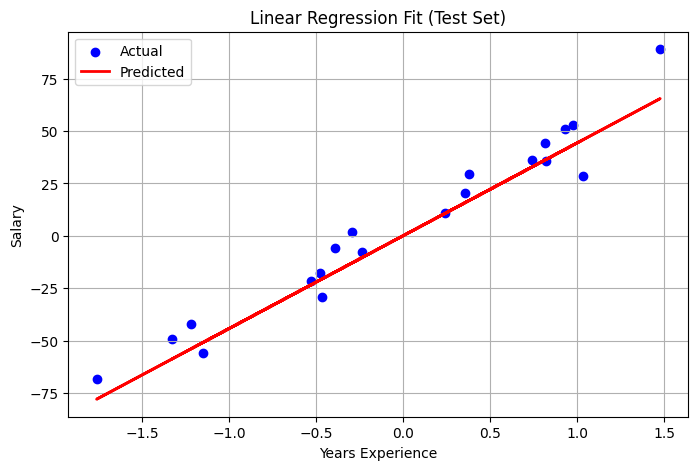

In [11]:
# --------------------------
# 7. Visualize the regression line
# --------------------------
plt.figure(figsize=(8,5))
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Predicted')
plt.xlabel('Years Experience')
plt.ylabel('Salary')
plt.title('Linear Regression Fit (Test Set)')
plt.legend()
plt.grid(True)
plt.savefig('regression_line.png')
plt.show()



In [12]:
# --------------------------
# 8. Save the model
# --------------------------
os.makedirs('models', exist_ok=True)
joblib.dump(model, 'models/salary_model.pkl')
print("\nModel saved to 'models/salary_model.pkl'")


Model saved to 'models/salary_model.pkl'
